# Training Notebook — Synthetic Shapes Dataset

Generates a synthetic instance segmentation dataset (circles, rectangles, triangles), registers it with Detectron2, and runs training to validate the full pipeline.

Code below is for setting up the collab envoirment 

In [1]:
!git clone https://github.com/RibaDiba/SensAug-D2.git /content/sensaug-d2 2>/dev/null || git -C /content/sensaug-d2 pull
%cd /content/sensaug-d2
!pip install -r requirements.txt -q

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 788 bytes | 788.00 KiB/s, done.
From https://github.com/RibaDiba/SensAug-D2
   c31a967..9407532  main       -> origin/main
Updating c31a967..9407532
Fast-forward
 hooks/IoU_val_hook.py | 16 ++++++++++++----
 1 file changed, 12 insertions(+), 4 deletions(-)
/content/sensaug-d2
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done


In [10]:
# in case of changes, reload the packges 
# %load_ext autoreload
# %autoreload 2

ModuleNotFoundError: No module named 'imp'

In [4]:
import json
import os
import random
from pathlib import Path

import cv2
import numpy as np

from training_scripts.train import register_instances, train

## 1. Generate Synthetic Shapes Dataset

Standard for testing the workflow, here for now to make sure everything works before moving on to creating the sensitivity anaylsis hook

In [5]:
IMG_W, IMG_H = 256, 256
MIN_RADIUS, MAX_RADIUS = 15, 50
MAX_OBJECTS = 5
CATEGORY = {"id": 1, "name": "circle", "supercategory": "shape"}


def random_color():
    return [random.randint(60, 255) for _ in range(3)]


def generate_image_and_annotations(image_id, ann_id_start):
    img = np.random.randint(20, 80, (IMG_H, IMG_W, 3), dtype=np.uint8)
    annotations = []
    ann_id = ann_id_start
    num_objects = random.randint(1, MAX_OBJECTS)

    for _ in range(num_objects):
        r = random.randint(MIN_RADIUS, MAX_RADIUS)
        cx = random.randint(r + 1, IMG_W - r - 1)
        cy = random.randint(r + 1, IMG_H - r - 1)
        color = random_color()

        cv2.circle(img, (cx, cy), r, color, -1)

        # Build polygon segmentation (circle approximated as polygon)
        angles = np.linspace(0, 2 * np.pi, 32, endpoint=False)
        poly_x = (cx + r * np.cos(angles)).tolist()
        poly_y = (cy + r * np.sin(angles)).tolist()
        seg = []
        for px, py in zip(poly_x, poly_y):
            seg.extend([round(px, 1), round(py, 1)])

        x_min = max(0, cx - r)
        y_min = max(0, cy - r)
        w = min(IMG_W, cx + r) - x_min
        h = min(IMG_H, cy + r) - y_min

        annotations.append({
            "id": ann_id,
            "image_id": image_id,
            "category_id": 1,
            "segmentation": [seg],
            "area": float(np.pi * r * r),
            "bbox": [x_min, y_min, w, h],
            "iscrowd": 0,
        })
        ann_id += 1

    return img, annotations, ann_id


def generate_split(split_dir, num_images):
    os.makedirs(split_dir, exist_ok=True)
    images_info = []
    all_annotations = []
    ann_id = 1

    for i in range(num_images):
        filename = f"{i:04d}.png"
        img, anns, ann_id = generate_image_and_annotations(i, ann_id)
        cv2.imwrite(os.path.join(split_dir, filename), img)

        images_info.append({
            "id": i,
            "file_name": filename,
            "width": IMG_W,
            "height": IMG_H,
        })
        all_annotations.extend(anns)

    coco = {
        "images": images_info,
        "annotations": all_annotations,
        "categories": [CATEGORY],
    }

    split_name = os.path.basename(split_dir)
    json_path = os.path.join(split_dir, f"{split_name}.json")
    with open(json_path, "w") as f:
        json.dump(coco, f)

    print(f"  {split_name}: {num_images} images, {len(all_annotations)} instances -> {json_path}")

In [6]:
DATASET_DIR = "data/toy"

random.seed(42)
np.random.seed(42)

print("Generating toy dataset...")
generate_split(os.path.join(DATASET_DIR, "train"), num_images=30)
generate_split(os.path.join(DATASET_DIR, "val"), num_images=8)
generate_split(os.path.join(DATASET_DIR, "test"), num_images=8)
print("Done!")

Generating toy dataset...
  train: 30 images, 98 instances -> data/toy/train/train.json
  val: 8 images, 22 instances -> data/toy/val/val.json
  test: 8 images, 26 instances -> data/toy/test/test.json
Done!


## 2. Register Dataset & Train

[05/28 05:05:17 d2.data.datasets.coco]: Loaded 30 images in COCO format from data/toy/train/train.json
[05/28 05:05:17 d2.data.datasets.coco]: Loaded 8 images in COCO format from data/toy/test/test.json
[05/28 05:05:17 d2.data.datasets.coco]: Loaded 8 images in COCO format from data/toy/val/val.json
[05/28 05:05:18 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1

roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}
roi_heads.mask_head.predictor.{bias, weight}


[05/28 05:05:18 d2.engine.train_loop]: Starting training from iteration 0


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0528 05:05:19.159000 13665 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


[05/28 05:05:26 d2.utils.events]:  eta: 0:01:45  iter: 19  total_loss: 1.672  loss_cls: 0.328  loss_box_reg: 0.835  loss_mask: 0.4509  loss_rpn_cls: 0.009611  loss_rpn_loc: 0.01026    time: 0.3836  last_time: 0.4015  data_time: 0.0156  last_data_time: 0.0067   lr: 0.000442  max_mem: 1932M
[05/28 05:05:38 d2.utils.events]:  eta: 0:01:39  iter: 39  total_loss: 0.9327  loss_cls: 0.1182  loss_box_reg: 0.6902  loss_mask: 0.1541  loss_rpn_cls: 0.001041  loss_rpn_loc: 0.008837    time: 0.3846  last_time: 0.3705  data_time: 0.0066  last_data_time: 0.0067   lr: 0.000802  max_mem: 1932M
[05/28 05:05:45 d2.utils.events]:  eta: 0:01:28  iter: 59  total_loss: 0.3654  loss_cls: 0.06865  loss_box_reg: 0.2178  loss_mask: 0.06818  loss_rpn_cls: 0.0001412  loss_rpn_loc: 0.006724    time: 0.3760  last_time: 0.4152  data_time: 0.0071  last_data_time: 0.0074   lr: 0.001  max_mem: 1932M
[05/28 05:05:53 d2.utils.events]:  eta: 0:01:21  iter: 79  total_loss: 0.2782  loss_cls: 0.04952  loss_box_reg: 0.1593  lo

AttributeError: 'IoUHook' object has no attribute 'model_name'

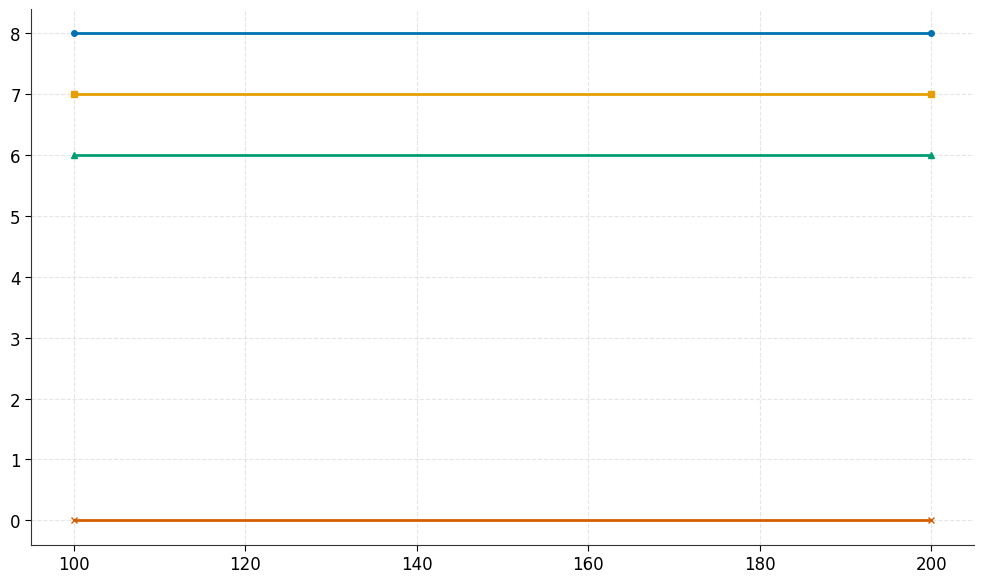

In [7]:
from detectron2 import model_zoo

# Register the synthetic dataset splits
register_instances(DATASET_DIR)

BASE_MODEL = "COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"

config = {
    "BASE_MODEL": BASE_MODEL,
    "JOBNAME": "toy_circle_test",
    "EVAL_PERIOD": 100,

    "MODEL": {
        "WEIGHTS": model_zoo.get_checkpoint_url(BASE_MODEL),
        "ROI_HEADS": {
            "NUM_CLASSES": 1,
            "BATCH_SIZE_PER_IMAGE": 128,
            "SCORE_THRESH_TEST": 0.3,
        },
    },

    "DATASETS": {
        "TRAIN": ["my_dataset_train"],
        "TEST": ["my_dataset_test", "my_dataset_val"],
    },

    "DATALOADER": {
        "NUM_WORKERS": 2,
        "FILTER_EMPTY_ANNOTATIONS": False,
    },

    "SOLVER": {
        "MAX_ITER": 300,
        "IMS_PER_BATCH": 2,
        "BASE_LR": 0.001,
        "STEPS": [200, 250],
        "GAMMA": 0.5,
        "WARMUP_ITERS": 50,
        "WARMUP_FACTOR": 0.1,
    },

    "OUTPUT_DIR": "model_output/",
}

train(config)